In [2]:
!pip install lightkurve

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 75.9 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=77f6c651d2fcc075c402ac7dc22a9d66b366cd0408a3fe0fcc79325bf98c866e
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f622795b09e83471a3be5d2581cd9cf96a6ec7aa78e8deffe
  Created wheel for memoization:

In [3]:
import lightkurve as lk
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from astropy import units as u

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [4]:
search = lk.search_targetpixelfile("Kepler-10", mission="Kepler")

In [5]:
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,60,kplr011904151,0.0
1,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
2,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
4,Kepler Quarter 00,2009,Kepler,1800,kplr011904151,0.0
5,Kepler Quarter 01,2009,Kepler,1800,kplr011904151,0.0
6,Kepler Quarter 02,2009,Kepler,1800,kplr011904151,0.0
7,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
8,Kepler Quarter 07,2010,Kepler,60,kplr011904151,0.0


In [6]:
tpf = search.download()

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 49 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [7]:
tpf

KeplerTargetPixelFile Object (ID: 11904151)

<Axes: title={'center': 'Target ID: 11904151, Cadence: 122650'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

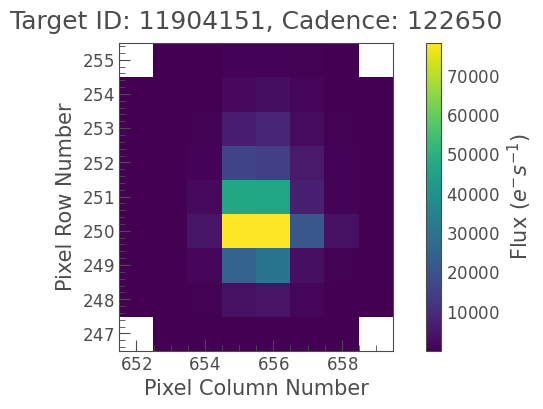

In [8]:
tpf.plot()

In [9]:
aperture_mask = tpf.pipeline_mask

<Axes: title={'center': 'Target ID: 11904151, Cadence: 122650'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

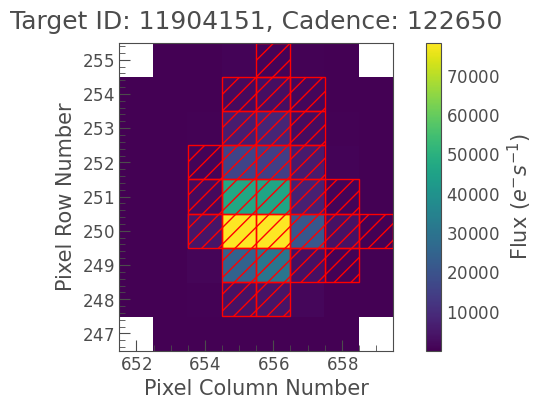

In [10]:
tpf.plot(aperture_mask=aperture_mask)

In [11]:
lc = tpf.to_lightcurve(aperture_mask=aperture_mask)

<Axes: title={'center': 'Target ID: 11904151, Cadence: 122650'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

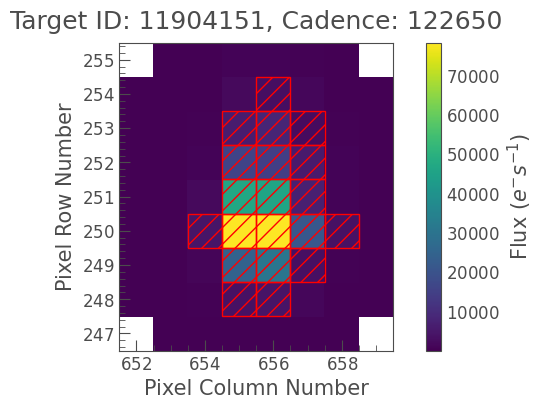

In [12]:
aperture_mask = tpf.create_threshold_mask(threshold=3)
tpf.plot(aperture_mask=aperture_mask)

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

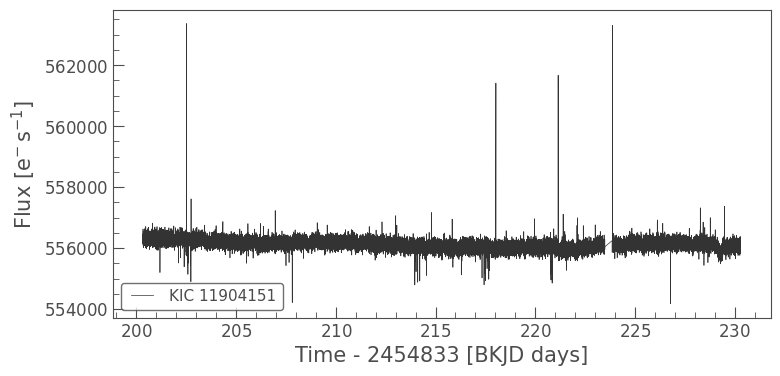

In [13]:
lc.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

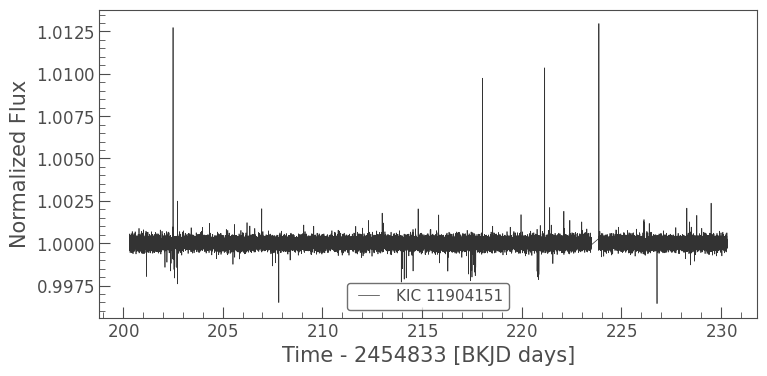

In [14]:
flat_lc = lc.flatten(window_length=401)
flat_lc.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

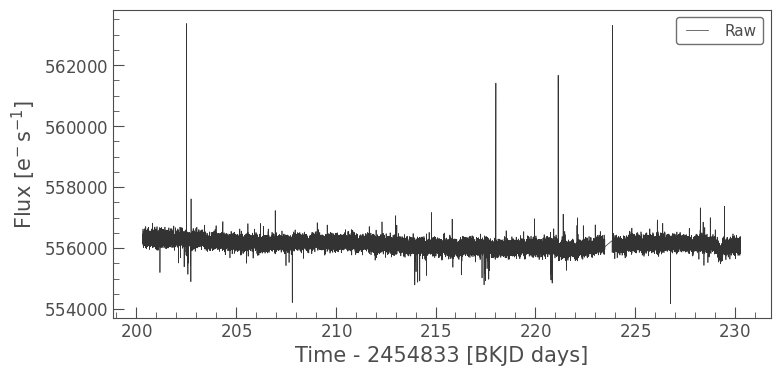

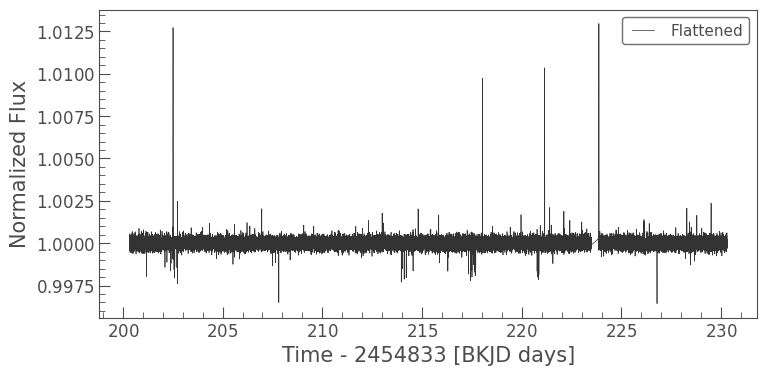

In [15]:
lc = lc.remove_nans()
flat_lc = lc.flatten(window_length=401)
lc.plot(label="Raw")
flat_lc.plot(label="Flattened")

In [16]:
flat_lc.to_csv("flattened_lightcurve.csv",overwrite=True)

In [17]:
from google.colab import files

files.download('flattened_lightcurve.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Detected Period: 0.8372837283728374 d


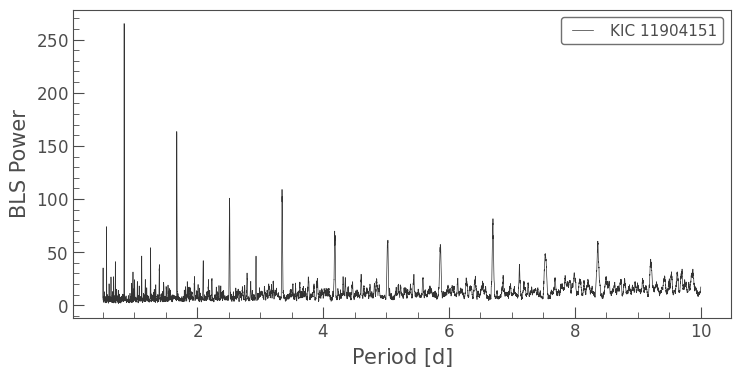

In [18]:
import numpy as np

# Define period range
periods = np.linspace(0.5, 10, 10000)

# Run BLS
bls = flat_lc.to_periodogram(method="bls", period=periods)

# Plot
bls.plot()

# Extract best period
best_period = bls.period_at_max_power
print("Detected Period:", best_period)

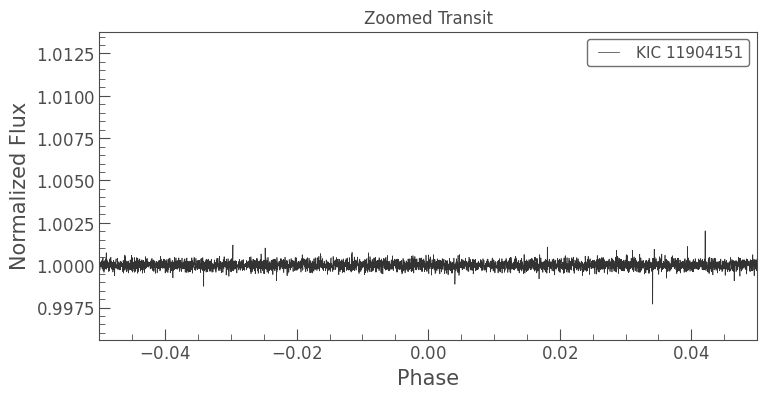

In [19]:
import matplotlib.pyplot as plt

# Plot folded light curve
folded_lc = flat_lc.fold(period=best_period, epoch_time=best_period/2)
ax = folded_lc.plot()

# Zoom into transit
ax.set_xlim(-0.05, 0.05)

# Improve visualization
plt.title("Zoomed Transit")
plt.xlabel("Phase")
plt.ylabel("Normalized Flux")

plt.show()

In [20]:
flux = folded_lc.flux

# Sort flux values
sorted_flux = np.sort(flux)

# Take median of lowest values (robust)
transit_depth = 1 - np.median(sorted_flux[:50])

print("Transit Depth:", transit_depth)

Transit Depth: 0.0014742307358892592


In [21]:
flux = folded_lc.flux

# Remove NaNs if any
flux = flux[~np.isnan(flux)]

# Robust depth calculation
sorted_flux = np.sort(flux)
transit_depth = 1 - np.median(sorted_flux[:100])

In [22]:
rp_rs = np.sqrt(transit_depth)
print("Rp/Rs:", rp_rs)

Rp/Rs: 0.0294166440348949


In [23]:
print("===== EXOPLANET PARAMETERS =====")
print(f"Orbital Period: {best_period:.4f} days")
print(f"Transit Depth: {transit_depth:.6f}")
print(f"Rp/Rs: {rp_rs:.4f}")

===== EXOPLANET PARAMETERS =====
Orbital Period: 0.8373 d days
Transit Depth: 0.000865
Rp/Rs: 0.0294


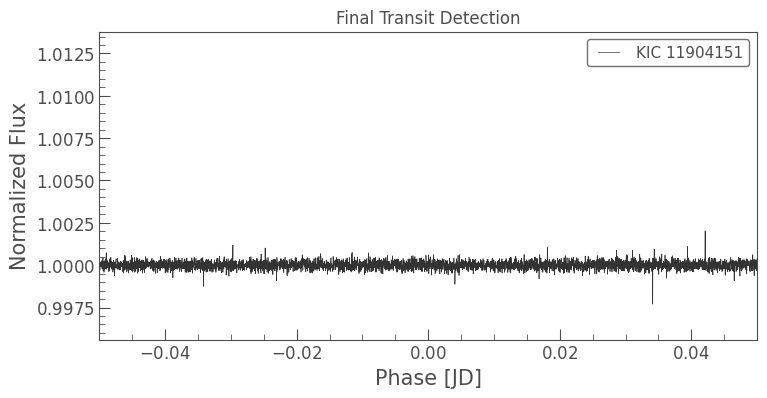

In [24]:
ax = folded_lc.plot()
ax.set_xlim(-0.05, 0.05)
plt.title("Final Transit Detection")
plt.show()